In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
teca_df = pd.read_csv('TECAClassificationData.csv')
teca_df.head(20)

,ID,high_gpm,loyalty_customer,revenue,quarter,income,bachelors_degree,population,num_trans,basket,refill,area,items_sold
0,247813,0.0,0.0,6.35,3.0,43438.0,51.0,279.0,1.0,0.0,0.0,tobacco,1.0
1,17692,0.0,0.0,1.33,1.0,58594.0,1167.0,8624.0,1.0,0.0,0.0,alcohol,1.0
2,219791,0.0,0.0,5.00,3.0,59468.0,3808.0,22756.0,1.0,0.0,0.0,lottery,1.0
3,975250,0.0,0.0,5.74,2.0,38516.0,665.0,9515.0,1.0,0.0,0.0,tobacco,1.0
4,658408,0.0,0.0,6.01,2.0,52379.0,4088.0,41584.0,1.0,0.0,0.0,tobacco,1.0
5,1579784,1.0,0.0,1.29,2.0,61115.0,264.0,2048.0,1.0,0.0,0.0,dispensed,1.0
6,1613075,1.0,0.0,1.00,4.0,69084.0,8337.0,51804.0,1.0,0.0,0.0,dispensed,1.0
7,965547,0.0,0.0,10.49,3.0,44112.0,1649.0,19064.0,1.0,0.0,0.0,alcohol,1.0
8,159563,1.0,0.0,1.96,3.0,54614.0,1739.0,23523.0,1.0,0.0,0.0,cooler,1.0
9,1373306,0.0,0.0,10.00,1.0,65861.0,164.0,1730.0,1.0,0.0,0.0,fuel,1.0


In [ ]:
teca_df_prep = pd.get_dummies(teca_df, drop_first=True, dtype=int)
teca_df_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63239 entries, 0 to 63238
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  63239 non-null  int64  
 1   high_gpm            63238 non-null  float64
 2   loyalty_customer    63238 non-null  float64
 3   revenue             63238 non-null  float64
 4   quarter             63238 non-null  float64
 5   income              63238 non-null  float64
 6   bachelors_degree    63238 non-null  float64
 7   population          63238 non-null  float64
 8   num_trans           63238 non-null  float64
 9   basket              63238 non-null  float64
 10  refill              63238 non-null  float64
 11  items_sold          63238 non-null  float64
 12  area_cooler         63239 non-null  int64  
 13  area_dispensed      63239 non-null  int64  
 14  area_fresh          63239 non-null  int64  
 15  area_fuel           63239 non-null  int64  
 16  area

In [ ]:
from sklearn.model_selection import train_test_split

x = teca_df_prep[['loyalty_customer', 'revenue', 'quarter', 'income',
       'bachelors_degree', 'population', 'num_trans', 'basket', 'refill',
       'items_sold', 'area_cooler', 'area_dispensed', 'area_fresh',
       'area_fuel', 'area_grocery', 'area_lottery', 'area_miscellaneous',
       'area_nongrocery', 'area_snacks', 'area_tobacco']]
y = teca_df_prep[['high_gpm']]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=42)
display(x_train.head(), y_train.head())

,loyalty_customer,revenue,quarter,income,bachelors_degree,population,num_trans,basket,refill,items_sold,area_cooler,area_dispensed,area_fresh,area_fuel,area_grocery,area_lottery,area_miscellaneous,area_nongrocery,area_snacks,area_tobacco
2683,0.0,1.89,1.0,60422.0,1883.0,15059.0,1.0,0.0,0.0,1.0,1,0,0,0,0,0,0,0,0,0
60554,0.0,5.49,3.0,38571.0,71.0,873.0,1.0,0.0,0.0,1.0,1,0,0,0,0,0,0,0,0,0
47120,0.0,3.19,3.0,50052.0,111.0,1125.0,1.0,0.0,0.0,1.0,0,0,0,0,1,0,0,0,0,0
33852,0.0,1.50,4.0,50739.0,1730.0,15507.0,1.0,0.0,0.0,1.0,0,0,0,0,0,0,0,0,1,0
26793,0.0,5.51,1.0,62508.0,2139.0,17311.0,1.0,0.0,0.0,1.0,0,0,0,0,0,0,0,0,0,1


,high_gpm
2683,0.0
60554,1.0
47120,0.0
33852,1.0
26793,0.0


In [ ]:
import statsmodels.api as sm
import pandas as pd

# Combine x_train and y_train to drop rows with NaNs consistently
train_data = pd.concat([x_train, y_train], axis=1)
train_data.dropna(inplace=True)

# Separate x_train_cleaned and y_train_cleaned
y_train_cleaned = train_data['high_gpm']
x_train_cleaned = train_data.drop(columns='high_gpm')

# Add constant to the cleaned x_train
x_train_const = sm.add_constant(x_train_cleaned)

# Check for columns with zero variance in x_train_const (excluding the 'const' column)
zero_var_cols = x_train_const.columns[(x_train_const.var() == 0) & (x_train_const.columns != 'const')]

if not zero_var_cols.empty:
    print(f"Warning: Columns with zero variance found in x_train_const: {list(zero_var_cols)}. Dropping them.")
    x_train_const = x_train_const.drop(columns=zero_var_cols)

# Check if y_train_cleaned has only one unique value (complete separation)
if y_train_cleaned.nunique() < 2:
    print("Error: y_train_cleaned contains only one unique value, logistic regression cannot be performed.")
else:
    log_reg = sm.Logit(y_train_cleaned, x_train_const).fit()

         Current function value: 0.289242
         Iterations: 35


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
log_reg.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                   Results: Logit
=====================================================================================
Model:                      Logit                  Method:                 MLE       
Dependent Variable:         high_gpm               Pseudo R-squared:       0.565     
Date:                       2026-06-21 07:43       AIC:                    21989.4429
No. Observations:           37943                  BIC:                    22160.3197
Df Model:                   19                     Log-Likelihood:         -10975.   
Df Residuals:               37923                  LL-Null:                -25240.   
Converged:                  0.0000                 LLR p-value:            0.0000    
No. Iterations:             35.0000                Scale:                  1.0000    
-------------------------------------------------------------------------------------
                    Coef.      Std.Err.      z    P>|z|      [0.025         0.975]   
-------------------------------------------------------------------------------------
const              -29.0431      236.5946 -0.1228 0.9023      -492.7600      434.6739
revenue             -0.0063        0.0060 -1.0500 0.2937        -0.0181        0.0055
quarter              0.0840        0.0144  5.8279 0.0000         0.0557        0.1122
income               0.0000        0.0000  4.4954 0.0000         0.0000        0.0000
bachelors_degree    -0.0001        0.0000 -4.1469 0.0000        -0.0001       -0.0000
population           0.0000        0.0000  3.5373 0.0004         0.0000        0.0000
num_trans           11.6260      197.0791  0.0590 0.9530      -374.6420      397.8940
basket             -11.3971      197.0793 -0.0578 0.9539      -397.6654      374.8713
refill              -7.3119   117670.9910 -0.0001 1.0000   -230638.2163   230623.5925
items_sold           0.0794        0.0320  2.4776 0.0132         0.0166        0.1422
area_cooler         16.4205      130.9077  0.1254 0.9002      -240.1539      272.9949
area_dispensed      48.4285   117299.2441  0.0004 0.9997   -229853.8653   229950.7223
area_fresh          18.4514      130.9077  0.1409 0.8879      -238.1230      275.0258
area_fuel          -13.9060    57763.2170 -0.0002 0.9998   -113227.7310   113199.9189
area_grocery        16.3261      130.9077  0.1247 0.9007      -240.2483      272.9005
area_lottery       -24.2367 18307930.3906 -0.0000 1.0000 -35882908.4338 35882859.9604
area_miscellaneous  -6.7655     4658.5848 -0.0015 0.9988     -9137.4239     9123.8929
area_nongrocery     18.2223      130.9077  0.1392 0.8893      -238.3521      274.7968
area_snacks         17.2237      130.9077  0.1316 0.8953      -239.3507      273.7981
area_tobacco       -16.3583   263286.2389 -0.0001 1.0000   -516047.9043   516015.1876
=====================================================================================

"""

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight = 'balanced')
lr.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced')

In [ ]:
import pandas as pd

# Combine x_test and y_test to drop rows with NaNs consistently
test_data = pd.concat([x_test, y_test], axis=1)
test_data.dropna(inplace=True)

# Separate x_test_cleaned and y_test_cleaned
y_test_cleaned = test_data['high_gpm']
x_test_cleaned = test_data.drop(columns='high_gpm')

lr_predictions = lr.predict(x_test_cleaned)
FullTestLRDf = pd.concat([x_test_cleaned, y_test_cleaned], axis=1)
FullTestLRDf['Predicted_Values'] = lr_predictions
FullTestLRDf.head()

,loyalty_customer,revenue,quarter,income,bachelors_degree,population,num_trans,basket,refill,items_sold,...,area_fresh,area_fuel,area_grocery,area_lottery,area_miscellaneous,area_nongrocery,area_snacks,area_tobacco,high_gpm,Predicted_Values
55689,0.0,2.99,4.0,132230.0,974.0,3294.0,1.0,0.0,0.0,1.0,...,1,0,0,0,0,0,0,0,1.0,1.0
3944,0.0,1.66,4.0,85130.0,7618.0,30714.0,1.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0.0,0.0
57930,0.0,31.18,4.0,58520.0,533.0,7692.0,1.0,0.0,0.0,1.0,...,0,1,0,0,0,0,0,0,0.0,0.0
26070,0.0,1.29,3.0,132230.0,974.0,3294.0,1.0,0.0,0.0,1.0,...,1,0,0,0,0,0,0,0,0.0,1.0
273,0.0,2.18,1.0,48125.0,21.0,658.0,1.0,0.0,0.0,2.0,...,0,0,0,0,0,0,0,0,1.0,1.0


In [ ]:
from sklearn import metrics

cm_lr = metrics.confusion_matrix(y_test_cleaned, lr_predictions)

print(cm_lr)

[[12635  3036]
 [ 2054  7570]]


In [ ]:
true_negative, false_positive, false_negative, true_positive = cm_lr.ravel()

print(f"True Positives (TP), : {true_positive}")
print(f"True Negatives (TN), Rejection: {true_negative}")
print(f"False Positives (FP), Type I Error: {false_positive}")
print(f"False Negatives (FN), Type II Error: {false_negative}")

True Positives (TP), : 7570
True Negatives (TN), Rejection: 12635
False Positives (FP), Type I Error: 3036
False Negatives (FN), Type II Error: 2054


In [ ]:
Accuracy = metrics.accuracy_score(y_test_cleaned, lr_predictions)
Precision = metrics.precision_score(y_test_cleaned, lr_predictions)
Sensitivity = metrics.recall_score(y_test_cleaned, lr_predictions)
Specificity = metrics.recall_score(y_test_cleaned, lr_predictions, pos_label=0)
Negative_Predictive_Value = metrics.precision_score(y_test_cleaned, lr_predictions, pos_label=0)

print(f'Accuracy (TP+TN)/(TP+TN+FP+FN): {Accuracy}')
print(f'Precision/Positive Predictive Value TP/(TP+FP): {Precision}')
print(f'Sensitivity/Recall/Hit Rate/True Positive Rate TP/(TP+FN): {Sensitivity}')
print(f'Specificity/Selectivity/True Negative Rate TN/(TN+FP): {Specificity}')
print(f'Negative Predictive Value TN/(TN+FN): {Negative_Predictive_Value}')

Accuracy (TP+TN)/(TP+TN+FP+FN): 0.7987744613559992
Precision/Positive Predictive Value TP/(TP+FP): 0.7137469356967754
Sensitivity/Recall/Hit Rate/True Positive Rate TP/(TP+FN): 0.7865752285951787
Specificity/Selectivity/True Negative Rate TN/(TN+FP): 0.8062663518601237
Negative Predictive Value TN/(TN+FN): 0.8601674722581524


In [ ]:
teca_df_prep_dtc = pd.get_dummies(teca_df, dtype=int)

In [ ]:
x_dtc = teca_df_prep_dtc[['loyalty_customer', 'revenue', 'quarter', 'income',
       'bachelors_degree', 'population', 'num_trans', 'basket', 'refill',
       'items_sold', 'area_alcohol', 'area_cooler', 'area_dispensed', 'area_fresh',
       'area_fuel', 'area_grocery', 'area_lottery', 'area_miscellaneous',
       'area_nongrocery', 'area_snacks', 'area_tobacco']]
y_dtc = teca_df_prep_dtc[['high_gpm']]

x_train_dtc, x_test_dtc, y_train_dtc, y_test_dtc = train_test_split(x_dtc, y_dtc, test_size=0.4, random_state=42)
display(x_train_dtc.head(), y_train_dtc.head())

,loyalty_customer,revenue,quarter,income,bachelors_degree,population,num_trans,basket,refill,items_sold,...,area_cooler,area_dispensed,area_fresh,area_fuel,area_grocery,area_lottery,area_miscellaneous,area_nongrocery,area_snacks,area_tobacco
2683,0.0,1.89,1.0,60422.0,1883.0,15059.0,1.0,0.0,0.0,1.0,...,1,0,0,0,0,0,0,0,0,0
60554,0.0,5.49,3.0,38571.0,71.0,873.0,1.0,0.0,0.0,1.0,...,1,0,0,0,0,0,0,0,0,0
47120,0.0,3.19,3.0,50052.0,111.0,1125.0,1.0,0.0,0.0,1.0,...,0,0,0,0,1,0,0,0,0,0
33852,0.0,1.50,4.0,50739.0,1730.0,15507.0,1.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,1,0
26793,0.0,5.51,1.0,62508.0,2139.0,17311.0,1.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,1


,high_gpm
2683,0.0
60554,1.0
47120,0.0
33852,1.0
26793,0.0


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(class_weight = 'balanced', max_depth=6, random_state=42)

dtc = dtc.fit(x_train_dtc, y_train_dtc)

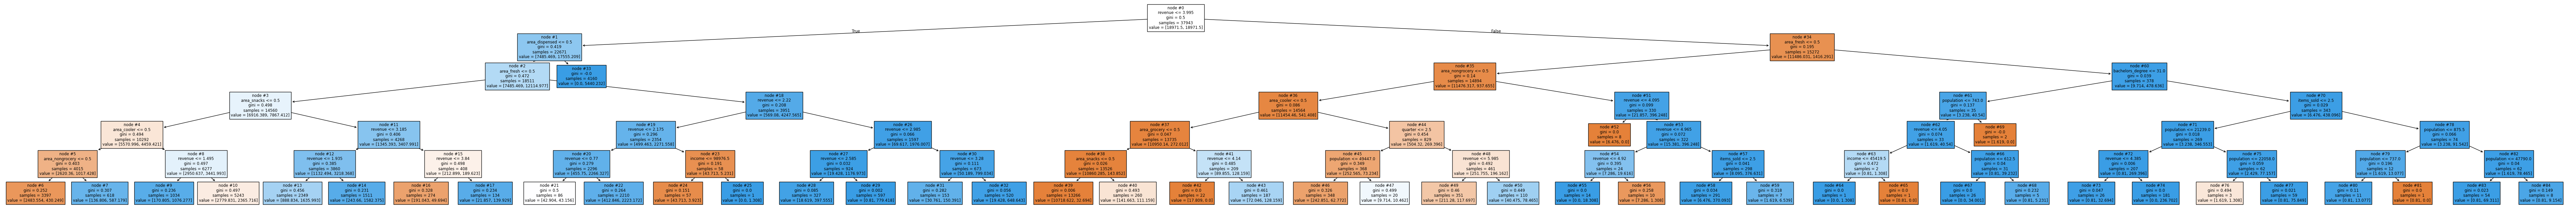

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(100,8))
plot_tree(dtc,
          filled=True,
          feature_names=x_train_dtc.columns,
          node_ids = True);

In [ ]:
feature_importance = (pd.DataFrame({'Feature': x_train_dtc.columns,
                                    'Importance': dtc.feature_importances_})
                     .sort_values('Importance', ascending=False))
feature_importance

,Feature,Importance
1,revenue,0.559502
13,area_fresh,0.138383
12,area_dispensed,0.103709
18,area_nongrocery,0.097576
19,area_snacks,0.047815
11,area_cooler,0.038603
15,area_grocery,0.011793
2,quarter,0.001431
5,population,0.000850
3,income,0.000262


In [ ]:
dtc_predictions = dtc.predict(x_test_dtc)
FullTestDtcDf = pd.concat([x_test_dtc, y_test_dtc], axis=1)
FullTestDtcDf['Predicted_Values'] = dtc_predictions
FullTestDtcDf.head(10)

,loyalty_customer,revenue,quarter,income,bachelors_degree,population,num_trans,basket,refill,items_sold,...,area_fresh,area_fuel,area_grocery,area_lottery,area_miscellaneous,area_nongrocery,area_snacks,area_tobacco,high_gpm,Predicted_Values
55689,0.0,2.99,4.0,132230.0,974.0,3294.0,1.0,0.0,0.0,1.0,...,1,0,0,0,0,0,0,0,1.0,1.0
3944,0.0,1.66,4.0,85130.0,7618.0,30714.0,1.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0.0,0.0
57930,0.0,31.18,4.0,58520.0,533.0,7692.0,1.0,0.0,0.0,1.0,...,0,1,0,0,0,0,0,0,0.0,0.0
26070,0.0,1.29,3.0,132230.0,974.0,3294.0,1.0,0.0,0.0,1.0,...,1,0,0,0,0,0,0,0,0.0,1.0
273,0.0,2.18,1.0,48125.0,21.0,658.0,1.0,0.0,0.0,2.0,...,0,0,0,0,0,0,0,0,1.0,1.0
34202,0.0,5.00,2.0,37695.0,713.0,11159.0,1.0,0.0,0.0,1.0,...,0,0,0,1,0,0,0,0,0.0,0.0
8742,0.0,3.92,2.0,70963.0,1959.0,16052.0,1.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,1,0.0,0.0
36823,0.0,6.00,3.0,62853.0,6708.0,43717.0,1.0,0.0,0.0,1.0,...,0,0,0,1,0,0,0,0,0.0,0.0
40844,0.0,3.42,1.0,57600.0,3483.0,24180.0,1.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,1,0.0,0.0
24313,0.0,1.29,2.0,53750.0,30.0,745.0,1.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,1.0,1.0


In [ ]:
from sklearn import metrics
import pandas as pd

# Identify non-NaN indices in y_test_dtc
non_nan_indices = y_test_dtc['high_gpm'].notna()

# Filter y_test_dtc and dtc_predictions to remove rows with NaNs
y_test_dtc_cleaned_for_cm = y_test_dtc[non_nan_indices]
dtc_predictions_cleaned_for_cm = dtc_predictions[non_nan_indices.values]

cm_dtc = metrics.confusion_matrix(y_test_dtc_cleaned_for_cm, dtc_predictions_cleaned_for_cm)

print(cm_dtc)

[[13869  1802]
 [ 1732  7892]]


In [ ]:
true_negative, false_positive, false_negative, true_positive = cm_dtc.ravel()

print(f"True Positives (TP), : {true_positive}")
print(f"True Negatives (TN), Rejection: {true_negative}")
print(f"False Positives (FP), Type I Error: {false_positive}")
print(f"False Negatives (FN), Type II Error: {false_negative}")

True Positives (TP), : 7892
True Negatives (TN), Rejection: 13869
False Positives (FP), Type I Error: 1802
False Negatives (FN), Type II Error: 1732


In [ ]:
Accuracy = metrics.accuracy_score(y_test_dtc_cleaned_for_cm, dtc_predictions_cleaned_for_cm)
Precision = metrics.precision_score(y_test_dtc_cleaned_for_cm, dtc_predictions_cleaned_for_cm)
Sensitivity = metrics.recall_score(y_test_dtc_cleaned_for_cm, dtc_predictions_cleaned_for_cm)
Specificity = metrics.recall_score(y_test_dtc_cleaned_for_cm, dtc_predictions_cleaned_for_cm, pos_label=0)
Negative_Predictive_Value = metrics.precision_score(y_test_dtc_cleaned_for_cm, dtc_predictions_cleaned_for_cm, pos_label=0)

print(f'Accuracy (TP+TN)/(TP+TN+FP+FN): {Accuracy}')
print(f'Precision/Positive Predictive Value TP/(TP+FP): {Precision}')
print(f'Sensitivity/Recall/Hit Rate/True Positive Rate TP/(TP+FN): {Sensitivity}')
print(f'Specificity/Selectivity/True Negative Rate TN/(TN+FP): {Specificity}')
print(f'Negative Predictive Value TN/(TN+FN): {Negative_Predictive_Value}')

Accuracy (TP+TN)/(TP+TN+FP+FN): 0.8602885945839098
Precision/Positive Predictive Value TP/(TP+FP): 0.8141118217454095
Sensitivity/Recall/Hit Rate/True Positive Rate TP/(TP+FN): 0.8200332502078138
Specificity/Selectivity/True Negative Rate TN/(TN+FP): 0.8850105290026163
Negative Predictive Value TN/(TN+FN): 0.8889814755464394


In [ ]:
teca_df_prep_knn = pd.get_dummies(teca_df, dtype=int)

In [ ]:
x_knn = teca_df_prep_knn[['loyalty_customer', 'revenue', 'quarter', 'income',
       'bachelors_degree', 'population', 'num_trans', 'basket', 'refill',
       'items_sold', 'area_alcohol', 'area_cooler', 'area_dispensed', 'area_fresh',
       'area_fuel', 'area_grocery', 'area_lottery', 'area_miscellaneous',
       'area_nongrocery', 'area_snacks', 'area_tobacco']]
y_knn = teca_df_prep_knn[['high_gpm']]

x_train_knn, x_test_knn, y_train_knn, y_test_knn = train_test_split(x_knn, y_knn, test_size=0.4, random_state=42)
display(x_train_knn.head(), y_train_knn.head())

,loyalty_customer,revenue,quarter,income,bachelors_degree,population,num_trans,basket,refill,items_sold,...,area_cooler,area_dispensed,area_fresh,area_fuel,area_grocery,area_lottery,area_miscellaneous,area_nongrocery,area_snacks,area_tobacco
2683,0.0,1.89,1.0,60422.0,1883.0,15059.0,1.0,0.0,0.0,1.0,...,1,0,0,0,0,0,0,0,0,0
60554,0.0,5.49,3.0,38571.0,71.0,873.0,1.0,0.0,0.0,1.0,...,1,0,0,0,0,0,0,0,0,0
47120,0.0,3.19,3.0,50052.0,111.0,1125.0,1.0,0.0,0.0,1.0,...,0,0,0,0,1,0,0,0,0,0
33852,0.0,1.50,4.0,50739.0,1730.0,15507.0,1.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,1,0
26793,0.0,5.51,1.0,62508.0,2139.0,17311.0,1.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,1


,high_gpm
2683,0.0
60554,1.0
47120,0.0
33852,1.0
26793,0.0


In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler().fit(x_train_knn)
x_train_sc = sc.transform(x_train_knn)
x_test_sc = sc.transform(x_test_knn)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=347)

knn.fit(x_train_sc, np.ravel(y_train_knn))

KNeighborsClassifier(n_neighbors=347)

In [ ]:
# Combine x_test_knn and y_test_knn to drop rows with NaNs consistently
test_data_knn = pd.concat([x_test_knn, y_test_knn], axis=1)
test_data_knn.dropna(inplace=True)

# Separate x_test_knn_cleaned and y_test_knn_cleaned
y_test_knn_cleaned = test_data_knn['high_gpm']
x_test_knn_cleaned = test_data_knn.drop(columns='high_gpm')

# Scale the cleaned test features
x_test_sc_cleaned = sc.transform(x_test_knn_cleaned)

# Make predictions on the cleaned and scaled test set
knn_predictions = knn.predict(x_test_sc_cleaned)

# Create the FullTestKnnDf with cleaned data and predictions
FullTestKnnDf = pd.concat([x_test_knn_cleaned, y_test_knn_cleaned], axis=1)
FullTestKnnDf['Predicted_Values'] = knn_predictions
FullTestKnnDf.head(10)

,loyalty_customer,revenue,quarter,income,bachelors_degree,population,num_trans,basket,refill,items_sold,...,area_fresh,area_fuel,area_grocery,area_lottery,area_miscellaneous,area_nongrocery,area_snacks,area_tobacco,high_gpm,Predicted_Values
55689,0.0,2.99,4.0,132230.0,974.0,3294.0,1.0,0.0,0.0,1.0,...,1,0,0,0,0,0,0,0,1.0,1.0
3944,0.0,1.66,4.0,85130.0,7618.0,30714.0,1.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0.0,0.0
57930,0.0,31.18,4.0,58520.0,533.0,7692.0,1.0,0.0,0.0,1.0,...,0,1,0,0,0,0,0,0,0.0,0.0
26070,0.0,1.29,3.0,132230.0,974.0,3294.0,1.0,0.0,0.0,1.0,...,1,0,0,0,0,0,0,0,0.0,1.0
273,0.0,2.18,1.0,48125.0,21.0,658.0,1.0,0.0,0.0,2.0,...,0,0,0,0,0,0,0,0,1.0,1.0
34202,0.0,5.00,2.0,37695.0,713.0,11159.0,1.0,0.0,0.0,1.0,...,0,0,0,1,0,0,0,0,0.0,0.0
8742,0.0,3.92,2.0,70963.0,1959.0,16052.0,1.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,1,0.0,0.0
36823,0.0,6.00,3.0,62853.0,6708.0,43717.0,1.0,0.0,0.0,1.0,...,0,0,0,1,0,0,0,0,0.0,0.0
40844,0.0,3.42,1.0,57600.0,3483.0,24180.0,1.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,1,0.0,0.0
24313,0.0,1.29,2.0,53750.0,30.0,745.0,1.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,1.0,1.0


In [ ]:
from sklearn import metrics

cm_knn = metrics.confusion_matrix(y_test_knn_cleaned, knn_predictions)

print(cm_knn)

[[13696  1975]
 [ 2233  7391]]


In [ ]:
true_negative, false_positive, false_negative, true_positive = cm_knn.ravel()

print(f"True Positives (TP), : {true_positive}")
print(f"True Negatives (TN), Rejection: {true_negative}")
print(f"False Positives (FP), Type I Error: {false_positive}")
print(f"False Negatives (FN), Type II Error: {false_negative}")

True Positives (TP), : 7391
True Negatives (TN), Rejection: 13696
False Positives (FP), Type I Error: 1975
False Negatives (FN), Type II Error: 2233


In [ ]:
Accuracy = metrics.accuracy_score(y_test_knn_cleaned, knn_predictions)
Precision = metrics.precision_score(y_test_knn_cleaned, knn_predictions)
Sensitivity = metrics.recall_score(y_test_knn_cleaned, knn_predictions)
Specificity = metrics.recall_score(y_test_knn_cleaned, knn_predictions, pos_label=0)
Negative_Predictive_Value = metrics.precision_score(y_test_knn_cleaned, knn_predictions, pos_label=0)

print(f'Accuracy (TP+TN)/(TP+TN+FP+FN): {Accuracy}')
print(f'Precision/Positive Predictive Value TP/(TP+FP): {Precision}')
print(f'Sensitivity/Recall/Hit Rate/True Positive Rate TP/(TP+FN): {Sensitivity}')
print(f'Specificity/Selectivity/True Negative Rate TN/(TN+FP): {Specificity}')
print(f'Negative Predictive Value TN/(TN+FN): {Negative_Predictive_Value}')

Accuracy (TP+TN)/(TP+TN+FP+FN): 0.8336430124530539
Precision/Positive Predictive Value TP/(TP+FP): 0.7891308989963699
Sensitivity/Recall/Hit Rate/True Positive Rate TP/(TP+FN): 0.767975893599335
Specificity/Selectivity/True Negative Rate TN/(TN+FP): 0.8739710292897709
Negative Predictive Value TN/(TN+FN): 0.8598154309749514
